# Marginally Consistent Redshift Assignment — demo

This notebook demonstrates the method described in the [README](README.md).

Each galaxy in a catalogue carries two discrete labels: a **lens-bin** index $i_L$ and a **source-bin** index $i_S$. We are given a target redshift distribution for every lens bin, $n^L_\ell(z)$, and every source bin, $n^S_s(z)$, but **not** the true redshifts. We learn a conditional density

$$q_\theta(z \mid i_L=\ell, i_S=s)$$

(a conditional **rational-quadratic neural spline flow**, `zuko.flows.NSF`) such that the label-weighted mixtures reproduce the supplied targets:

$$\hat n^L_{\ell,\theta}(z) = \sum_s p(s\mid\ell)\,q_\theta(z\mid\ell,s), \qquad \hat n^S_{s,\theta}(z) = \sum_\ell p(\ell\mid s)\,q_\theta(z\mid\ell,s),$$

trained with the forward-KL objective

$$\mathcal{L} = -\sum_\ell \mathbb{E}_{z\sim n^L_\ell}\big[\log \hat n^L_{\ell,\theta}(z)\big] - \sum_s \mathbb{E}_{z\sim n^S_s}\big[\log \hat n^S_{s,\theta}(z)\big].$$

**Demo setup:** 3 lens bins and 3 source bins, all overlapping, with the lens bins at slightly lower redshift than the source bins. The synthetic ground truth is a parent Smail distribution $n(z)\propto z^\alpha e^{-(z/z_0)^\beta}$ split into tomographic bins by soft redshift selection windows.

> Requires `zuko` (`pip install zuko`) in addition to PyTorch / NumPy / Matplotlib.

In [1]:
%matplotlib inline
import numpy as np
import torch
import matplotlib.pyplot as plt

import mcra

torch.manual_seed(0)
np.random.seed(0)
print("torch", torch.__version__)

torch 2.12.0


## 1. The synthetic demo problem

`mcra.make_demo_data()` builds a parent Smail population $n(z)$ and splits it into 3 lens bins and 3 source bins using soft Gaussian selection windows in redshift. The lens windows are centred *below* the source windows, so the supplied lens bins sit at slightly lower redshift than the source bins while all bins overlap.

Because every bin is a selection of the *same* parent population, the supplied targets are automatically **mutually compatible**: $\sum_\ell p(\ell)\,n^L_\ell(z) = \sum_s p(s)\,n^S_s(z) = n(z)$, so an exact solution exists.

The solver is only allowed to use:
- the supplied per-bin targets $n^L_\ell$, $n^S_s$ (which it can sample from), and
- the catalogue label statistics $p(s\mid\ell)$ and $p(\ell\mid s)$ (estimated from the two label columns).

It never sees the true redshifts or the true coupling.

In [2]:
data = mcra.make_demo_data()

print(f"{data.n_lens} lens bins, {data.n_source} source bins")
print("lens bin mean redshifts  :", np.round([t.mean for t in data.lens_targets], 3))
print("source bin mean redshifts:", np.round([t.mean for t in data.source_targets], 3))
print("\np(i_L):", np.round(data.p_l, 3))
print("p(i_S):", np.round(data.p_s, 3))
print("\np(i_S | i_L) rows=lens, cols=source:")
print(np.round(data.p_s_given_l, 3))

3 lens bins, 3 source bins
lens bin mean redshifts  : [0.355 0.566 0.984]
source bin mean redshifts: [0.429 0.69  1.087]

p(i_L): [0.213 0.236 0.552]
p(i_S): [0.366 0.238 0.397]

p(i_S | i_L) rows=lens, cols=source:
[[0.89  0.104 0.006]
 [0.554 0.351 0.096]
 [0.083 0.241 0.676]]


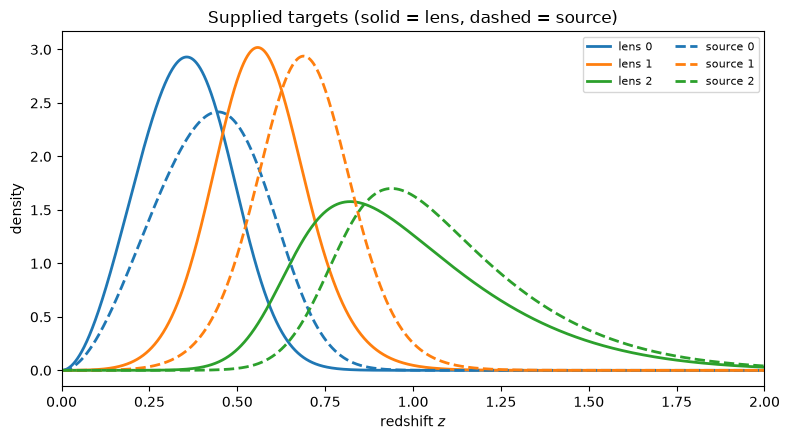

In [3]:
zg = data.z_grid
fig, ax = plt.subplots(figsize=(8, 4.5))
for l in range(data.n_lens):
    ax.plot(zg, data.lens_targets[l].pdf(zg), color=f"C{l}", lw=2,
            label=f"lens {l}")
for s in range(data.n_source):
    ax.plot(zg, data.source_targets[s].pdf(zg), color=f"C{s}", lw=2, ls="--",
            label=f"source {s}")
ax.set_xlim(0, 2.0)
ax.set_xlabel("redshift $z$"); ax.set_ylabel("density")
ax.set_title("Supplied targets (solid = lens, dashed = source)")
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
plt.show()

## 2. Build and train the conditional spline flow

`ConditionalRedshiftFlow` wraps a `zuko.flows.NSF` (monotonic rational-quadratic spline flow). The bin labels $(\ell, s)$ are fed to the flow as a concatenated one-hot context vector, and the flow operates on a standardised redshift $u = (z - \mu_0)/\sigma_0$.

We train with the forward-KL objective by sampling minibatches from the supplied targets and pushing the model-implied mixtures toward them.

In [4]:
model = mcra.ConditionalRedshiftFlow(
    data.n_lens, data.n_source,
    z_mean=data.z_mean, z_std=data.z_std,
    bins=8, transforms=3, hidden_features=[64, 64],
)

config = mcra.TrainConfig(
    steps=2000, batch_size=512, lr=2e-3,
    device="cpu", seed=0, log_every=250,
)
history = mcra.train(model, data, config)

step     0 | loss   3.6938 | lens   2.1064 | source   1.5874
step   250 | loss  -1.9831 | lens  -1.0501 | source  -0.9329
step   500 | loss  -2.0004 | lens  -1.0561 | source  -0.9442
step   750 | loss  -1.9199 | lens  -1.0811 | source  -0.8387
step  1000 | loss  -1.9910 | lens  -1.1421 | source  -0.8489
step  1250 | loss  -1.9510 | lens  -0.9895 | source  -0.9615
step  1500 | loss  -1.8946 | lens  -1.0070 | source  -0.8876
step  1750 | loss  -1.9224 | lens  -1.0019 | source  -0.9206
step  1999 | loss  -1.9537 | lens  -1.0405 | source  -0.9132


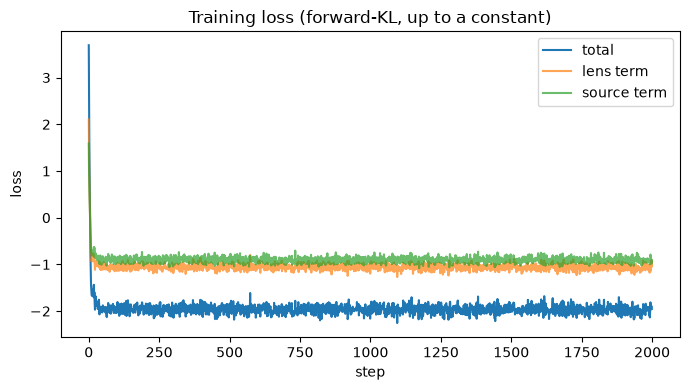

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(history["loss"], label="total")
ax.plot(history["lens_kl"], label="lens term", alpha=0.7)
ax.plot(history["source_kl"], label="source term", alpha=0.7)
ax.set_xlabel("step"); ax.set_ylabel("loss")
ax.set_title("Training loss (forward-KL, up to a constant)")
ax.legend()
fig.tight_layout()
plt.show()

## 3. Validation — do the model-implied marginals match the supplied targets?

The key check: for every lens bin the implied mixture $\hat n^L_\ell = \sum_s p(s\mid\ell)\,q_\theta(\cdot\mid\ell,s)$ should match the supplied $n^L_\ell$, and likewise for the source bins.

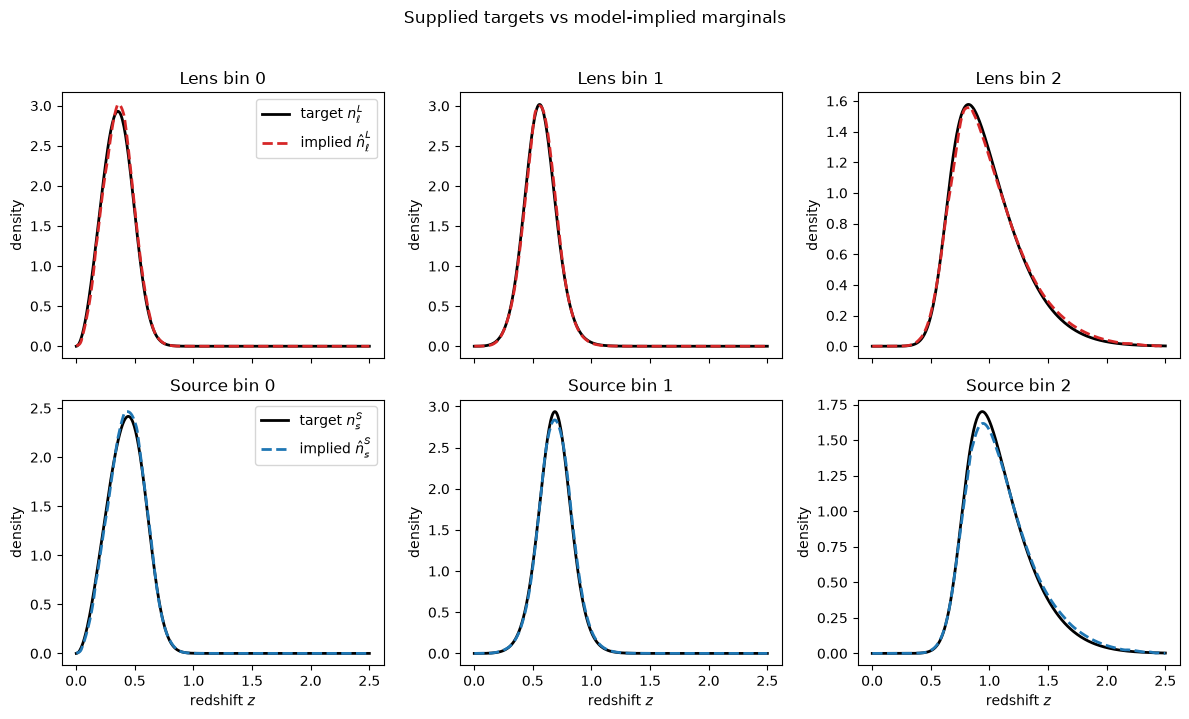

Per-bin agreement between supplied target and model-implied marginal:

               bin0  bin1  bin2
lens   KL    : 0.0018  0.0008  0.0022
lens   L1    : 0.0432  0.0257  0.0384
source KL    : 0.0011  0.0007  0.0028
source L1    : 0.0287  0.0280  0.0465


In [7]:
mcra.plot_marginals(model, data)
plt.show()

metrics = mcra.marginal_metrics(model, data)
print("Per-bin agreement between supplied target and model-implied marginal:\n")
print("              ", "  ".join(f"bin{ i}" for i in range(data.n_lens)))
print("lens   KL    :", "  ".join(f"{x:.4f}" for x in metrics["lens_kl"]))
print("lens   L1    :", "  ".join(f"{x:.4f}" for x in metrics["lens_l1"]))
print("source KL    :", "  ".join(f"{x:.4f}" for x in metrics["source_kl"]))
print("source L1    :", "  ".join(f"{x:.4f}" for x in metrics["source_l1"]))

## 4. The recovered conditional densities $q_\theta(z\mid\ell,s)$

The problem is underdetermined: many couplings reproduce the same marginals. With no regularisation the flow finds *a* valid solution. Here we overlay it with the (known) ground-truth coupling $q^*_{\ell s}$ used to build the demo. They need not match exactly — only the marginals are constrained — but with this compatible construction they come out close.

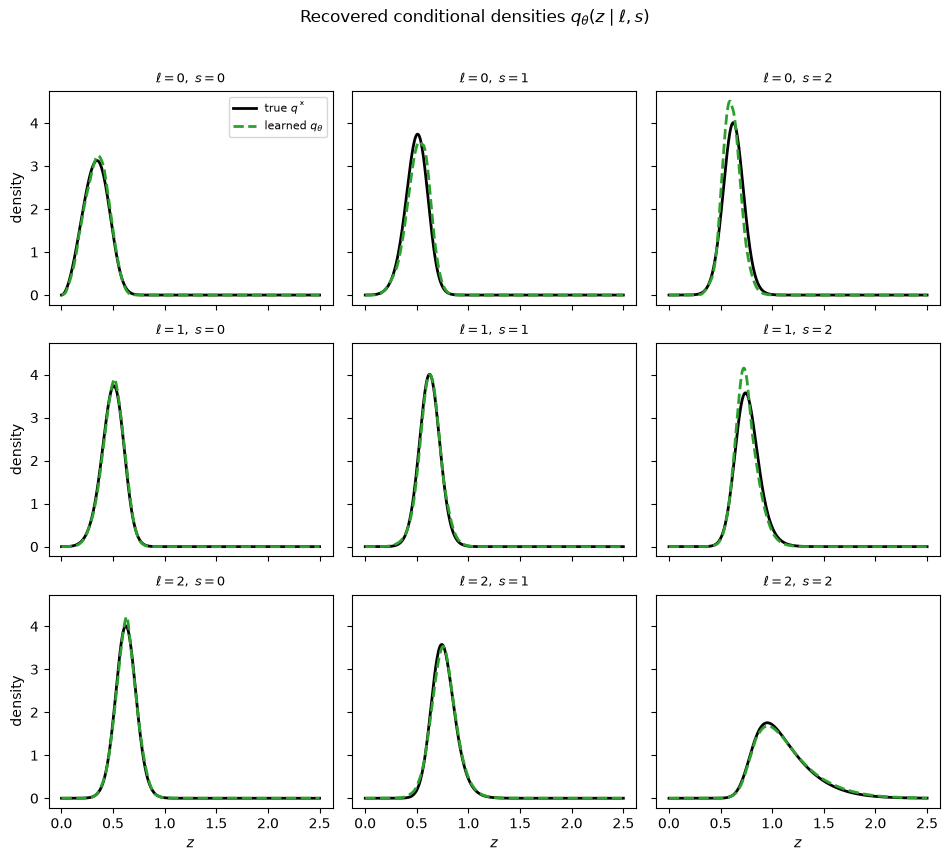

In [8]:
mcra.plot_conditionals(model, data)
plt.show()

## 5. Assign redshifts to a catalogue

Finally we use the trained flow exactly as intended: draw a catalogue of galaxies with labels $(i_L, i_S)$, assign each galaxy a redshift $z_g \sim q_\theta(z\mid i_L(g), i_S(g))$, and check that the resulting per-bin ensembles reproduce the supplied $n(z)$.

catalogue size: 200,000
assigned lens bin means  : [0.361 0.569 0.997]
target   lens bin means  : [0.355 0.566 0.984]
assigned source bin means: [0.433 0.692 1.103]
target   source bin means: [0.429 0.69  1.087]


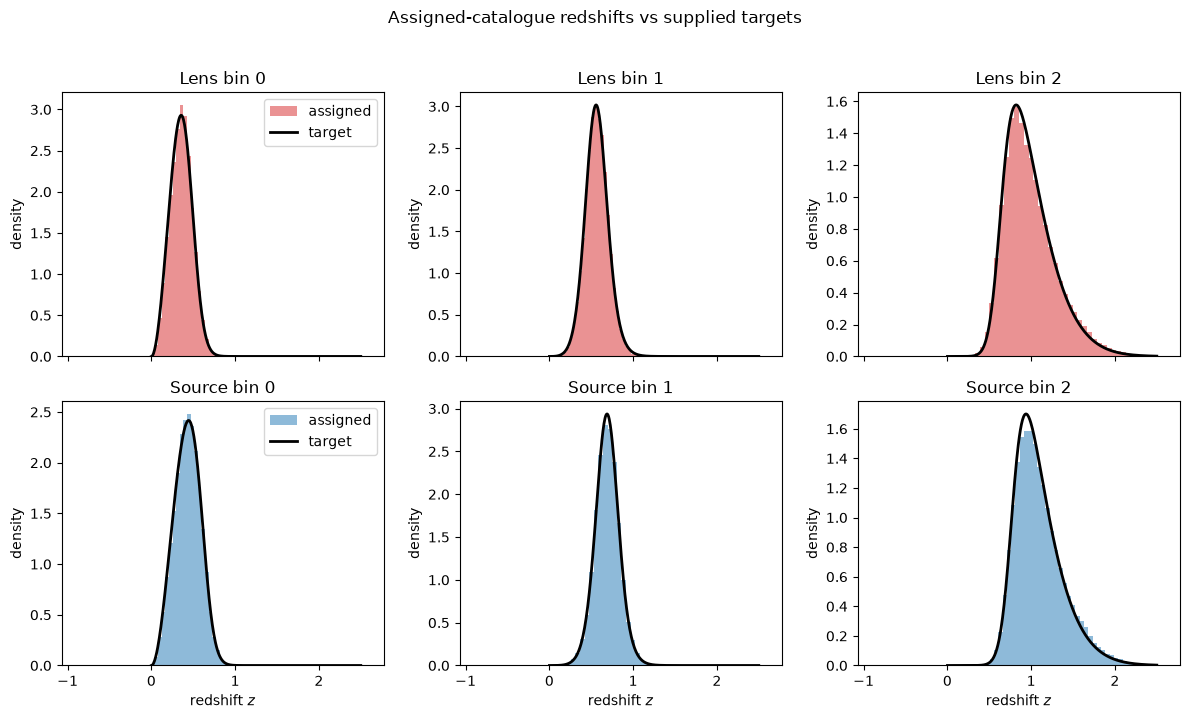

In [9]:
i_l, i_s, z_true = mcra.sample_catalogue(data, n=200_000, seed=1)
z_assigned = mcra.assign_redshifts(model, i_l, i_s)
print(f"catalogue size: {len(i_l):,}")
print("assigned lens bin means  :", np.round([z_assigned[i_l == l].mean() for l in range(data.n_lens)], 3))
print("target   lens bin means  :", np.round([t.mean for t in data.lens_targets], 3))
print("assigned source bin means:", np.round([z_assigned[i_s == s].mean() for s in range(data.n_source)], 3))
print("target   source bin means:", np.round([t.mean for t in data.source_targets], 3))

mcra.plot_catalogue(model, data, n=200_000, seed=1)
plt.show()